In [ ]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
from scripts.utils import setup_notebook, OKABE_ITO_CYCLE

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

# Backward-compatible alias
color_values = OKABE_ITO_CYCLE

In [ ]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "Theoretical calculations by Helen"
PLOTS_DIR    = PROJECT_ROOT / "figures"
PLOTS_DIR.mkdir(exist_ok=True)

In [4]:
print(type(color_values[0]), color_values[0])

<class 'str'> #E60000


In [5]:
M_along_Z = os.path.join(RAW_DATA_DIR, "M_AFM_FM_along_Z_21052025.xlsx")
excel_file = pd.ExcelFile(M_along_Z)

# Read Sheet2 and Sheet4 (Sheet3 is stored as 'Sheet4')
df_AFM = excel_file.parse('Sheet2', header=None)
df_FM = excel_file.parse('Sheet3', header=None)




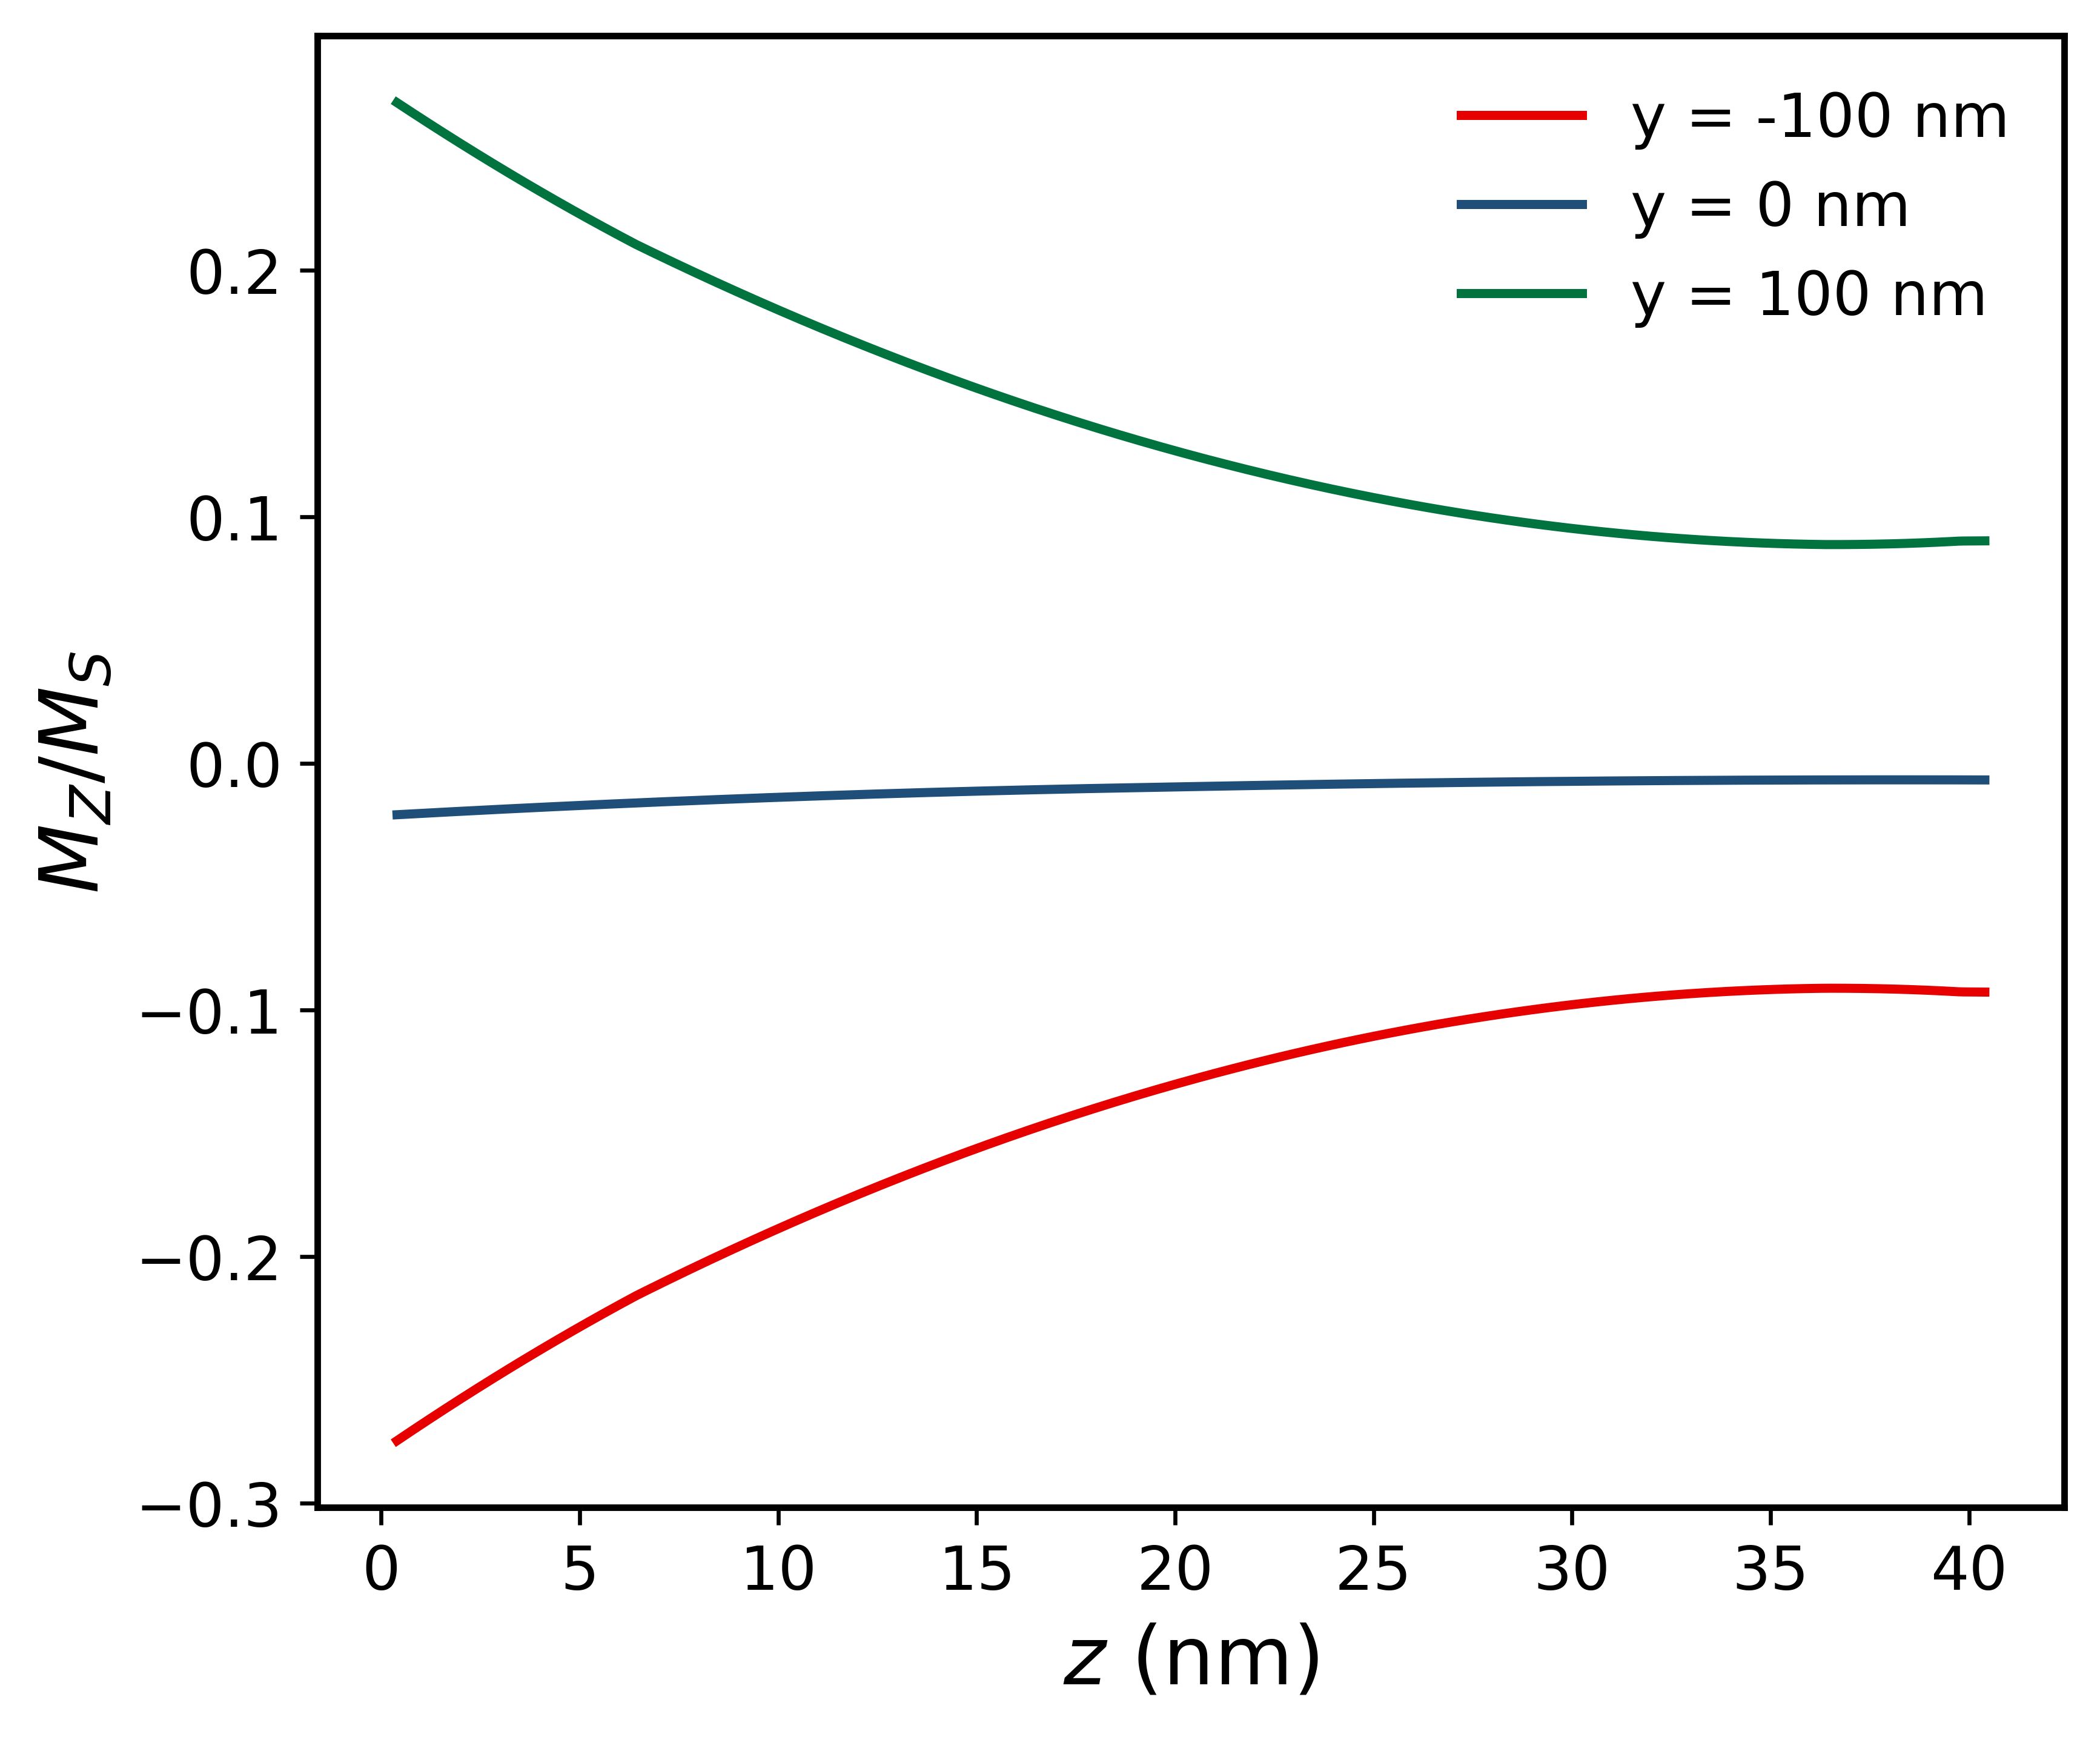

In [6]:
# Extract z and magnetization columns for x = -200, 0, 200 nm
z_vals = pd.to_numeric(df_AFM.iloc[5:, 0], errors="coerce")
AFM_mag_x_minus200 = pd.to_numeric(df_AFM.iloc[5:, 2], errors="coerce")
AFM_mag_x_0        = pd.to_numeric(df_AFM.iloc[5:, 5], errors="coerce")
AFM_mag_x_200      = pd.to_numeric(df_AFM.iloc[5:, 8], errors="coerce")

# Plot
plt.figure(figsize=(6, 5), dpi =600)
plt.plot(z_vals, AFM_mag_x_minus200, label="y = -100 nm", color=color_values[0])
plt.plot(z_vals, AFM_mag_x_0, label="y = 0 nm", color=color_values[1])
plt.plot(z_vals, AFM_mag_x_200, label="y = 100 nm", color=color_values[2])

plt.xlabel("$z$ (nm)")
plt.ylabel("$M_{Z}/M_{S}$")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "Theory_M_AFM_along_Z.png"), transparent = True)

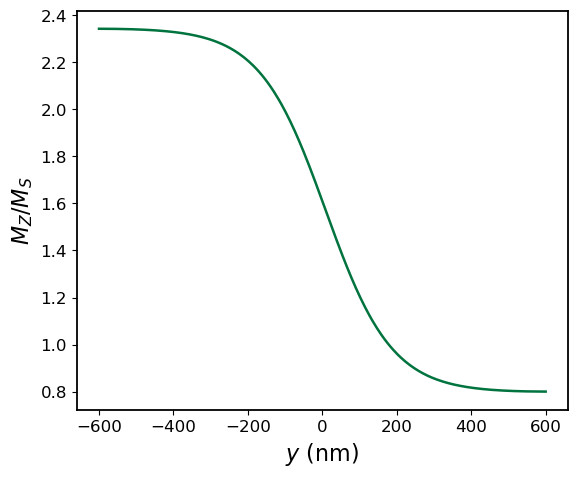

In [7]:

z_vals = pd.to_numeric(df_FM.iloc[5:, 0], errors="coerce")
FM_mag_Z_40 = pd.to_numeric(df_FM.iloc[5:, 2], errors="coerce")
FM_mag_Z_80        = pd.to_numeric(df_FM.iloc[5:, 5], errors="coerce")
FM_mag_Z_0      = pd.to_numeric(df_FM.iloc[5:, 8], errors="coerce")

# Plot
plt.figure(figsize=(6, 5))
plt.plot(z_vals, FM_mag_Z_0, label="x = 200 nm", color=color_values[2])

plt.xlabel("$y$ (nm)")
plt.ylabel("$M_{Z}/M_{S}$")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "Theory_M_FM_along_Y.png"))